In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [2]:
highalpha = pd.read_csv("../highalpha.csv")
lowalpha = pd.read_csv("../lowalpha.csv")

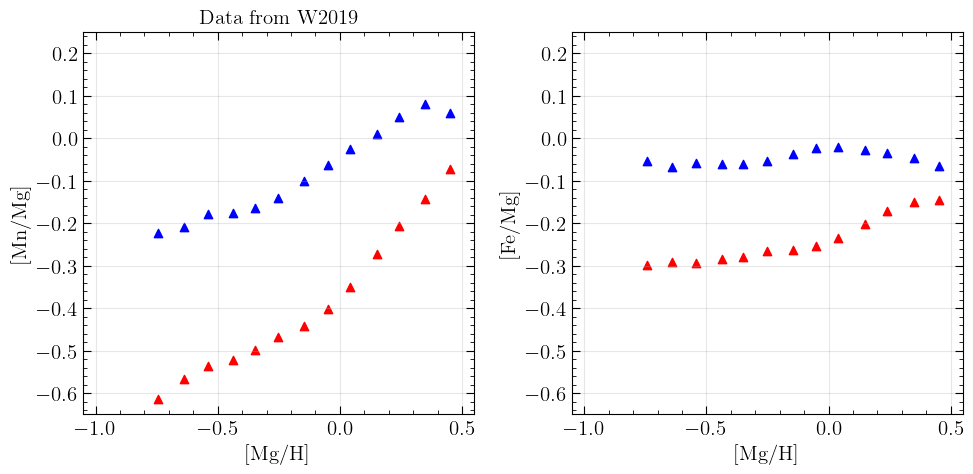

In [3]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue')
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')
plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

In [4]:
t_array = np.linspace(0.0001,14,int(1e3))
tau_sfh_def = 6 #Gyrs
tau_sfh_2 = 15 #Gyrs
m_g_array_exp_def = 1 * np.exp(-t_array/tau_sfh_def)
m_g_array_exp_2 = 1 * np.exp(-t_array/tau_sfh_2)
m_g_array_const = np.ones(len(t_array))

gal_def_2024 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_def)
gal_def_2017 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_def, solarvalues_ref="W2017", yields_ref="W2017")

etas = [0, 0.5, 0.95]
tau_stars = [1, 2, 5]
tau_Ia = 1.5

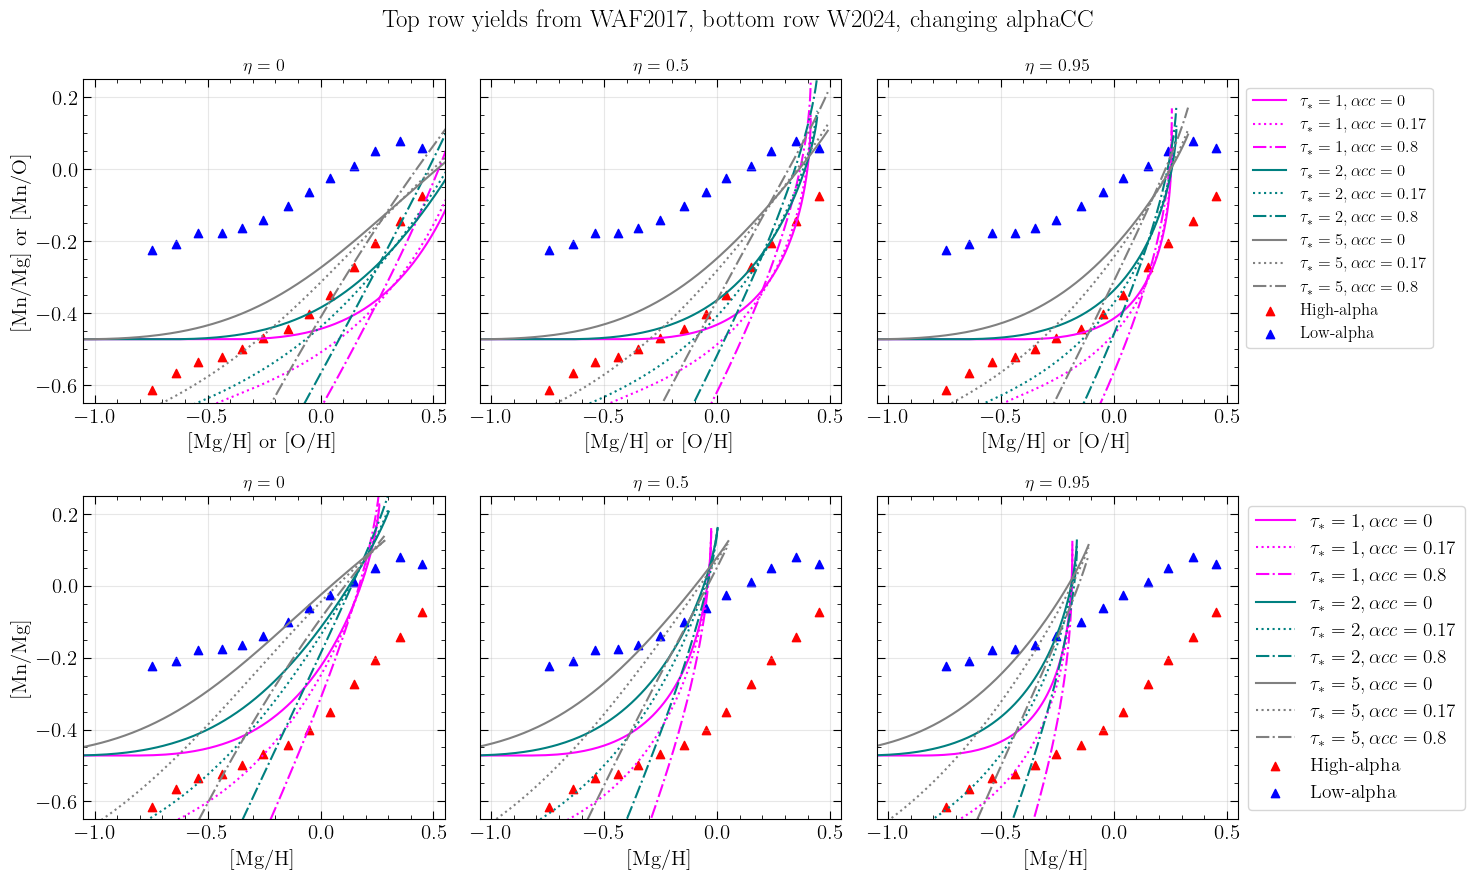

In [67]:
etas = [0, 0.5, 0.95]
tau_stars = [1, 2, 5]
tau_sfh = 15
tau_Ia = 1.5
linestyles = ['-', ':', '-.']
alpha_ccs = [0, 0.17, 0.8]
colors_2017 = ['magenta', 'teal', 'gray', 'green', 'orange']
colors_2024 = ['blue', 'red', 'black']

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

for i, eta in enumerate(etas):
    ax = axes[0][i]
    for j, taustar in enumerate(tau_stars):
        for k in range(len(alpha_ccs)):
            clr = colors_2017[j]
            gal_temp = evo.Galaxy(
                        t_array=t_array,
                        m_g_array=1 * np.exp(-t_array/tau_sfh),
                        eta=eta,
                        tau_star=taustar,
                        solarvalues_ref="W2017",
                        yields_ref="W2017",
                        alpha_cc_Mn=alpha_ccs[k]
                    )
            label = rf"$\tau_* = {taustar}, \alpha cc = {alpha_ccs[k]}$"
            ax.plot(gal_temp.O_H[1:], gal_temp.Mn_O[1:], 
                    label=label, color=clr, linestyle=linestyles[k])

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H] or [O/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg] or [Mn/O]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
        



for i, eta in enumerate(etas):
    ax = axes[1][i]
    for j, taustar in enumerate(tau_stars):
        for k, alpha_cc in enumerate(alpha_ccs):
            clr = colors_2017[j]
            gal_temp = evo.Galaxy(
                        t_array=t_array,
                        m_g_array=1 * np.exp(-t_array/tau_sfh),
                        eta=eta,
                        tau_star=taustar,
                        solarvalues_ref="W2024",
                        yields_ref="W2024",
                        alpha_cc_Mn=alpha_cc
                        )
            label = rf"$\tau_* = {taustar}, \alpha cc = {alpha_cc}$"
            ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Mn_Mg[1:], 
                    label=label, color=clr, linestyle=linestyles[k]
                    )

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)


plt.suptitle("Top row yields from WAF2017, bottom row W2024, changing alphaCC")
plt.tight_layout()
plt.show()


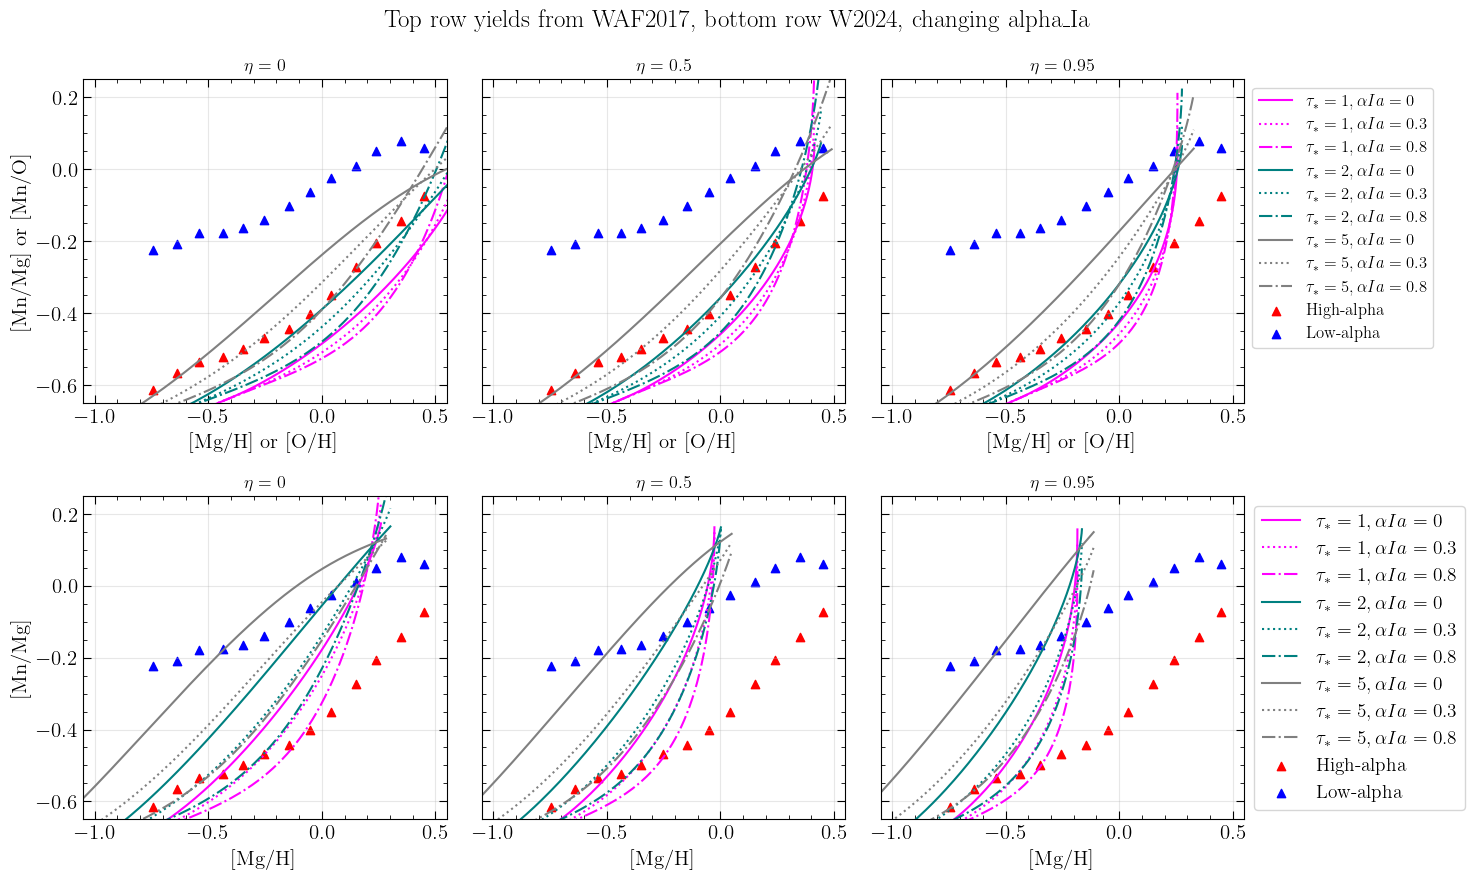

In [66]:
etas = [0, 0.5, 0.95]
tau_stars = [1, 2, 5]
tau_sfh = 6
tau_Ia = 1.5
linestyles = ['-', ':', '-.']
alpha_Ias = [0, 0.3, 0.8]
colors_2017 = ['magenta', 'teal', 'gray', 'green', 'orange']
colors_2024 = ['blue', 'red', 'black']

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

for i, eta in enumerate(etas):
    ax = axes[0][i]
    for j, taustar in enumerate(tau_stars):
        for k in range(len(alpha_Ias)):
            clr = colors_2017[j]
            gal_temp = evo.Galaxy(
                        t_array=t_array,
                        m_g_array=1 * np.exp(-t_array/tau_sfh_2),
                        tau_sfh=tau_sfh_2,
                        eta=eta,
                        tau_star=taustar,
                        solarvalues_ref="W2017",
                        yields_ref="W2017",
                        alpha_Ia_Mn=alpha_Ias[k]
                    )
            label = rf"$\tau_* = {taustar}, \alpha Ia = {alpha_Ias[k]}$"
            ax.plot(gal_temp.O_H[1:], gal_temp.Mn_O[1:], 
                    label=label, color=clr, linestyle=linestyles[k])

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H] or [O/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg] or [Mn/O]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
        



for i, eta in enumerate(etas):
    ax = axes[1][i]
    for j, taustar in enumerate(tau_stars):
        for k in range(len(alpha_Ias)):
            clr = colors_2017[j]
            gal_temp = evo.Galaxy(
                        t_array=t_array,
                        m_g_array=1 * np.exp(-t_array/tau_sfh_2),
                        tau_sfh=tau_sfh_2,
                        eta=eta,
                        tau_star=taustar,
                        solarvalues_ref="W2024",
                        yields_ref="W2024",
                        alpha_Ia_Mn=alpha_Ias[k]
                        )
            label = rf"$\tau_* = {taustar}, \alpha Ia = {alpha_Ias[k]}$"
            ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Mn_Mg[1:], 
                    label=label, color=clr, linestyle=linestyles[k]
                    )

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)


plt.suptitle("Top row yields from WAF2017, bottom row W2024, changing alpha_Ia")
plt.tight_layout()

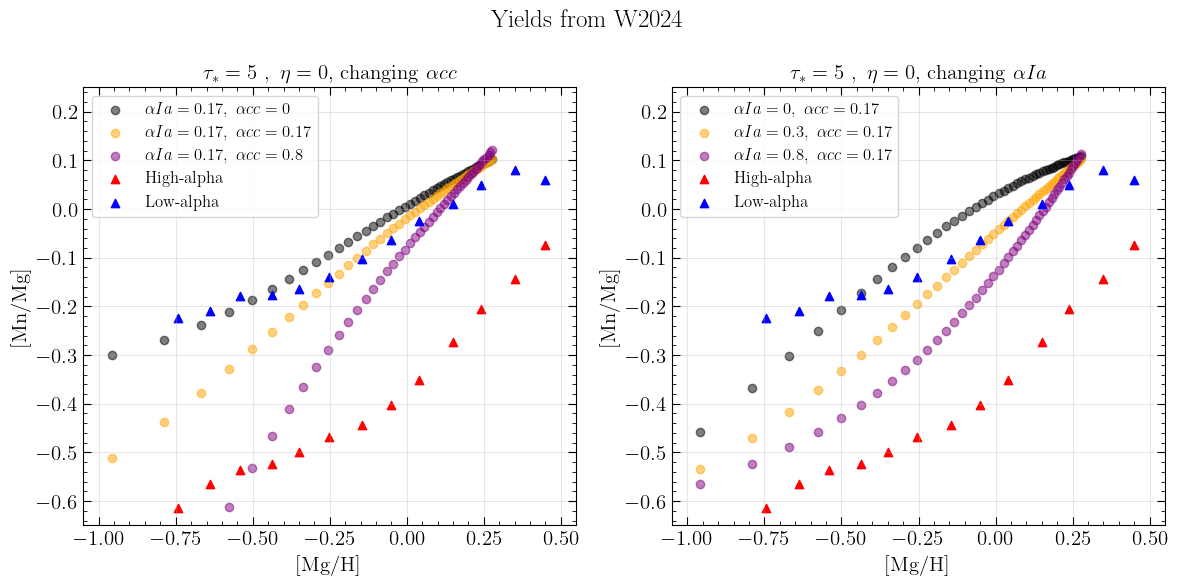

In [88]:
eta = 0
tau_star = 5
tau_sfh_eg = 15
m_g_array_eg = 1 * np.exp(-t_array/tau_sfh_eg)
tau_Ia = 1.5
linestyles = ['-', ':', '-.']
shapes = ['o', 's', 'd', '^', '*', 'hexagon']
alpha_ccs = [0, 0.17, 0.8]
alpha_Ias = [0, 0.3, 0.8]
colors = ['black', 'orange', 'purple', 'maroon', 'teal', 'olive']

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
for i in range(len(alpha_ccs)):
    alpha_cc=alpha_ccs[i]
    color = colors[i]
    alpha_Ia = 0.17
    shape = 'o'
    label = rf'$\alpha Ia = {alpha_Ia}, \ \alpha cc = {alpha_cc}$'
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=taustar, solarvalues_ref="W2024",
                              yields_ref="W2024", alpha_Ia_Mn=alpha_Ia, alpha_cc_Mn=alpha_cc, R_Ia_Mn=1.17)
    plt.scatter(gal_temp.Mg_H[1::20], gal_temp.Mn_Mg[1::20], color = color, marker=shape, alpha =0.5, label = label)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')


plt.title(rf'$\tau_* = {tau_star} \ , \ \eta = {eta}$, changing $\alpha cc$')
plt.xlim(-1.05, 0.55)
plt.ylim(-0.65, 0.25)
plt.grid(True, alpha=0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.legend(loc='upper left', fontsize=12)


plt.subplot(1,2,2)
for i in range(len(alpha_ccs)):
    alpha_cc=0.17
    color = colors[i]
    alpha_Ia = alpha_Ias[i]
    shape = 'o'
    label = rf'$\alpha Ia = {alpha_Ia}, \ \alpha cc = {alpha_cc}$'
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=taustar, solarvalues_ref="W2024",
                              yields_ref="W2024", alpha_Ia_Mn=alpha_Ia, alpha_cc_Mn=alpha_cc, R_Ia_Mn=1.17)
    plt.scatter(gal_temp.Mg_H[1::20], gal_temp.Mn_Mg[1::20], color = color, marker=shape, alpha =0.5, label = label)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')


plt.title(rf'$\tau_* = {tau_star} \ , \ \eta = {eta}$, changing $\alpha Ia$')
plt.xlim(-1.05, 0.55)
plt.ylim(-0.65, 0.25)
plt.grid(True, alpha=0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.legend(loc='upper left', fontsize=12)

plt.suptitle('Yields from W2024')
plt.tight_layout()

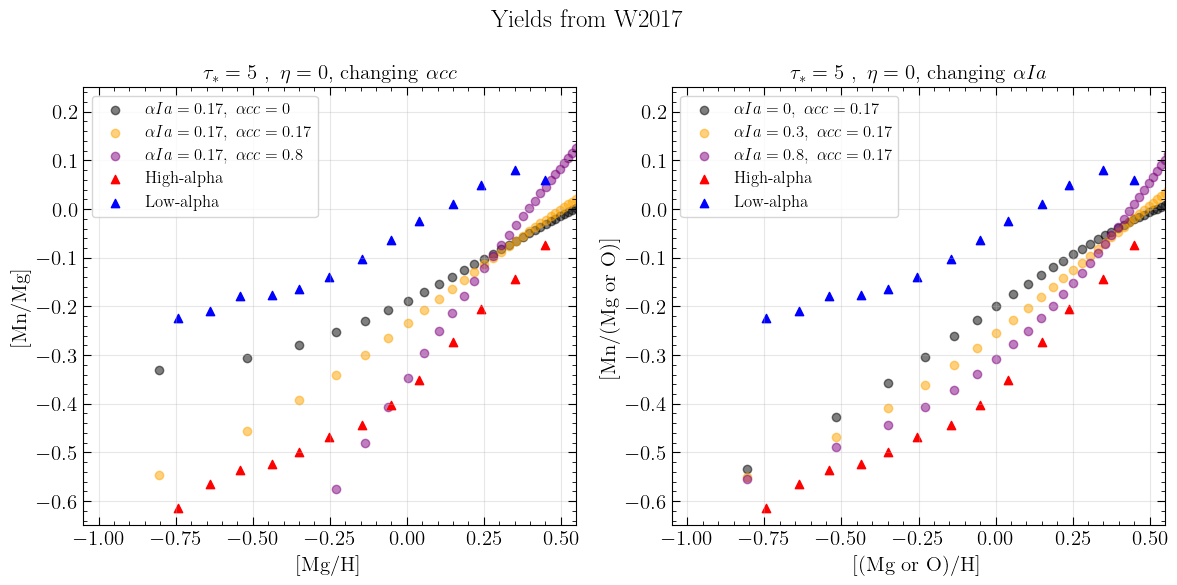

In [89]:
eta = 0
tau_star = 5
tau_sfh_eg = 15
m_g_array_eg = 1 * np.exp(-t_array/tau_sfh_eg)
tau_Ia = 1.5
linestyles = ['-', ':', '-.']
shapes = ['o', 's', 'd', '^', '*', 'hexagon']
alpha_ccs = [0, 0.17, 0.8]
alpha_Ias = [0, 0.3, 0.8]
colors = ['black', 'orange', 'purple', 'maroon', 'teal', 'olive']

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
for i in range(len(alpha_ccs)):
    alpha_cc=alpha_ccs[i]
    color = colors[i]
    alpha_Ia = 0.17
    shape = 'o'
    label = rf'$\alpha Ia = {alpha_Ia}, \ \alpha cc = {alpha_cc}$'
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=taustar, solarvalues_ref="W2017",
                              yields_ref="W2017", alpha_Ia_Mn=alpha_Ia, alpha_cc_Mn=alpha_cc, R_Ia_Mn=1.17)
    plt.scatter(gal_temp.O_H[1::20], gal_temp.Mn_O[1::20], color = color, marker=shape, alpha =0.5, label = label)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')


plt.title(rf'$\tau_* = {tau_star} \ , \ \eta = {eta}$, changing $\alpha cc$')
plt.xlim(-1.05, 0.55)
plt.ylim(-0.65, 0.25)
plt.grid(True, alpha=0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.legend(loc='upper left', fontsize=12)


plt.subplot(1,2,2)
for i in range(len(alpha_ccs)):
    alpha_cc=0.17
    color = colors[i]
    alpha_Ia = alpha_Ias[i]
    shape = 'o'
    label = rf'$\alpha Ia = {alpha_Ia}, \ \alpha cc = {alpha_cc}$'
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=taustar, solarvalues_ref="W2017",
                              yields_ref="W2017", alpha_Ia_Mn=alpha_Ia, alpha_cc_Mn=alpha_cc, R_Ia_Mn=1.17)
    plt.scatter(gal_temp.O_H[1::20], gal_temp.Mn_O[1::20], color = color, marker=shape, alpha =0.5, label = label)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')


plt.title(rf'$\tau_* = {tau_star} \ , \ \eta = {eta}$, changing $\alpha Ia$')
plt.xlim(-1.05, 0.55)
plt.ylim(-0.65, 0.25)
plt.grid(True, alpha=0.3)
plt.xlabel('[(Mg or O)/H]')
plt.ylabel('[Mn/(Mg or O)]')
plt.legend(loc='upper left', fontsize=12)

plt.suptitle('Yields from W2017')
plt.tight_layout()

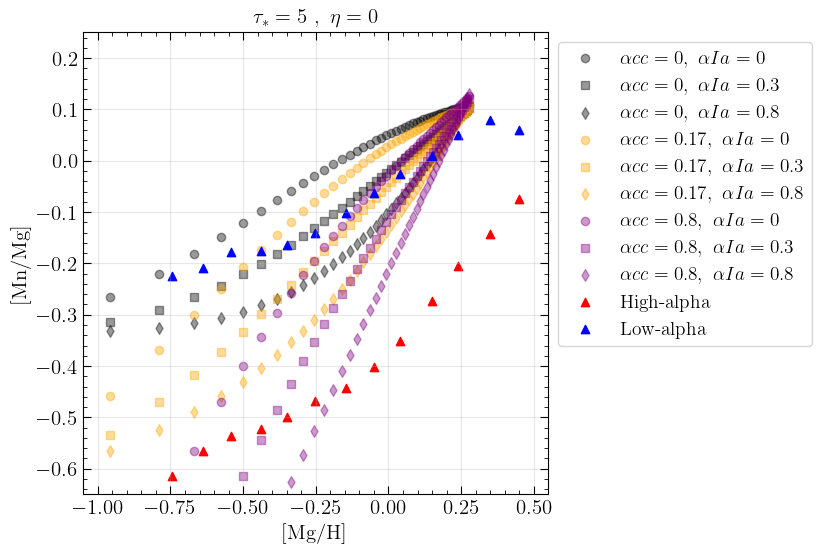

In [87]:
eta = 0
tau_star = 5
tau_sfh_eg = 15
m_g_array_eg = 1 * np.exp(-t_array/tau_sfh_eg)
tau_Ia = 1.5
linestyles = ['-', ':', '-.']
shapes = ['o', 's', 'd', '^', '*', 'hexagon']
alpha_ccs = [0, 0.17, 0.8]
alpha_Ias = [0, 0.3, 0.8]
colors = ['black', 'orange', 'purple', 'maroon', 'teal', 'olive']


plt.figure(figsize=(6,6))
for i in range(len(alpha_ccs)):
    alpha_cc=alpha_ccs[i]
    color = colors[i]
    for j in range(len(alpha_Ias)):
        alpha_Ia = alpha_Ias[j]
        shape = shapes[j]
        label = rf'$\alpha cc = {alpha_cc}, \ \alpha Ia = {alpha_Ia}$'
        gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=taustar, solarvalues_ref="W2024",
                              yields_ref="W2024", alpha_Ia_Mn=alpha_Ia, alpha_cc_Mn=alpha_cc, R_Ia_Mn=1.17)
        plt.scatter(gal_temp.Mg_H[1::20], gal_temp.Mn_Mg[1::20], color = color, marker=shape, alpha =0.4, label = label)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')


plt.title(rf'$\tau_* = {tau_star} \ , \ \eta = {eta}$')
plt.xlim(-1.05, 0.55)
plt.ylim(-0.65, 0.25)
plt.grid(True, alpha=0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)

# All in one plot!

Text(0, 0.5, '[Mn/Mg]')

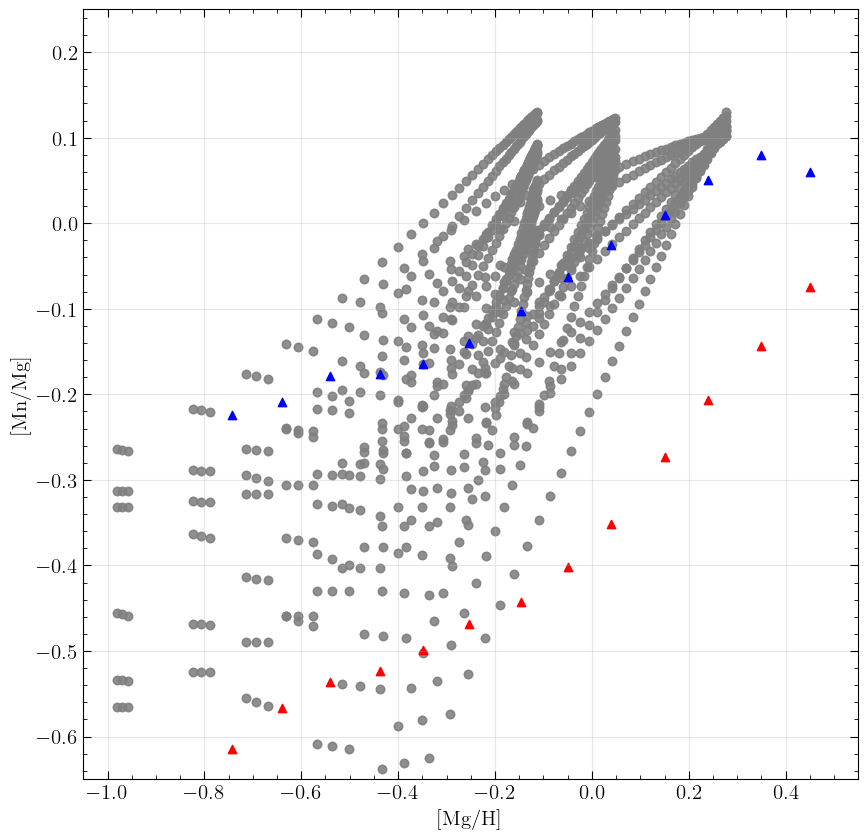

In [99]:
etas = [0, 0.5, 0.95]
tau_stars = [1, 2, 5]
tau_sfh = 15
tau_Ia = 1.5
alpha_ccs = [0, 0.17, 0.8]
alpha_Ias = [0, 0.3, 0.8]
linestyles = ['-', ':', '-.']
colors_tau_star = ['black', 'navy', 'purple', 'olive', 'green', 'teal', 'orange', 'magenta', 'choral']

plt.figure(figsize=(10,10))
color_index = 0
for i, eta in enumerate(etas):
    ls = linestyles[i]
    for j, tau_star in enumerate(tau_stars):
        for k, alpha_cc in enumerate(alpha_ccs):
            for f, alpha_Ia in enumerate(alpha_Ias):
                color = 'gray'
                label = rf'$\alpha cc = {alpha_cc}, \ \alpha Ia = {alpha_Ia}, \ \tau_* = {tau_star}, \ \eta = {eta}$'
                gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_eg, tau_sfh=tau_sfh_eg,
                              eta=eta, tau_star=taustar, solarvalues_ref="W2024",
                              yields_ref="W2024", alpha_Ia_Mn=alpha_Ia, alpha_cc_Mn=alpha_cc, R_Ia_Mn=1.17)
                plt.scatter(gal_temp.Mg_H[1::20], gal_temp.Mn_Mg[1::20], alpha =0.5, label = label, color = color)    
        
    
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')


#plt.title(rf'$\tau_* = {tau_star} \ , \ \eta = {eta}$')
plt.xlim(-1.05, 0.55)
plt.ylim(-0.65, 0.25)
plt.grid(True, alpha=0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
#plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)